In [1]:
import os, sys
import polars as pl
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
sns.set_style('whitegrid')
from BigEDA.plots import boxplot_matrix, histogram_matrix, barplot_matrix
from BigEDA.descriptive import outliers_table

In [2]:
DATA_ID = 'simulation_5' 
formatted_data_name = DATA_ID.replace('_', ' ').capitalize()

project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) 
sys.path.append(project_path)

from src.utils.simulations_utils import generate_simulation
from config.config_simulations import SIMULATION_CONFIGS
from config.config_experiment_5 import CONFIG_EXPERIMENT

simulation_config = SIMULATION_CONFIGS[DATA_ID]
config_experiment = CONFIG_EXPERIMENT[DATA_ID]

In [3]:
X, y, outliers_idx = generate_simulation(
    random_state = config_experiment['random_state'],
    n_samples = simulation_config['n_samples'],
    centers = simulation_config['centers'],
    cluster_std = simulation_config['cluster_std'],
    n_features = simulation_config['n_features'],
    outlier_configs = simulation_config['outlier_configs'],
    custom_sampling = False,  
    return_outlier_idx=True
)

X_pl = pl.from_pandas(X)

In [4]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8
0,-11.010788,-35.577322,5.369400,0.119920,0,1,1,1
1,-1.044792,-4.062543,-1.828567,7.173568,0,0,1,2
2,-19.552345,-14.977310,-15.157744,5.806335,1,1,1,3
3,-5.055414,-4.980831,2.078765,-0.971602,1,1,3,3
4,-3.086783,-15.462055,4.129252,6.076827,1,1,1,1


In [5]:
# Proportion of individuals per cluster/group
unique_values, counts = np.unique(y, return_counts=True)
prop_clusters = counts/len(y)
prop_clusters = {k: v for k, v in zip(unique_values, prop_clusters)}
print(f'prop_clusters: {prop_clusters}')

prop_clusters: {0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}


In [6]:
quant_predictors = ['X1', 'X2', 'X3', 'X4']
cat_predictors = ['X5', 'X6', 'X7', 'X8']

In [7]:
# Outliers information
outliers_table(X_pl, auto=False, col_names=quant_predictors, h=1.5)

quant_variables,lower_bound,upper_bound,n_outliers,n_not_outliers,prop_outliers,prop_not_outliers
str,f64,f64,i64,i64,f64,f64
"""X1""",-17.545317,14.887238,14103,285897,0.04701,0.95299
"""X2""",-14.126787,4.524058,27826,272174,0.092753,0.907247
"""X3""",-12.883403,6.579245,19726,280274,0.065753,0.934247
"""X4""",-6.178026,10.435668,1378,298622,0.004593,0.995407


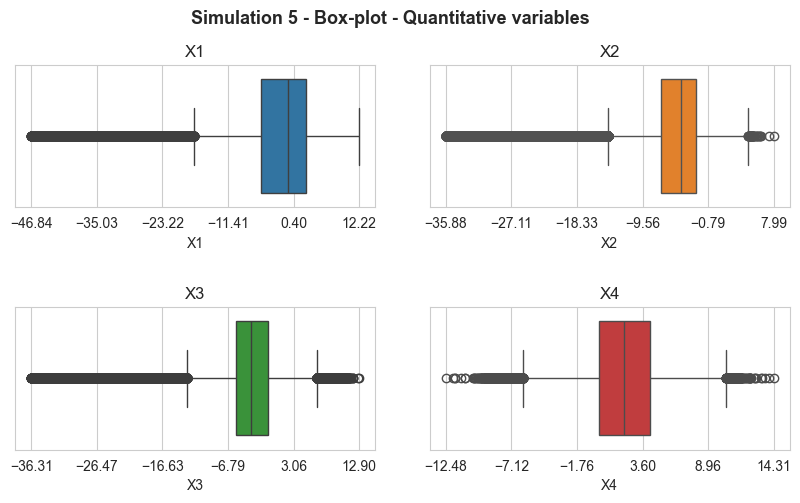

In [8]:
# Boxplot after outliers contamination
boxplot_matrix(X_pl, 
               n_cols=2, 
               title=f'{formatted_data_name} - Box-plot - Quantitative variables', 
               figsize=(10,5), 
               quant_col_names=quant_predictors, 
               n_xticks=6, 
               title_fontsize=13, 
               save=False, 
               file_name='', 
               x_rotation=0, 
               title_height=0.99,
               style='whitegrid', 
               hspace=0.7, 
               wspace=0.15, 
               title_weight='bold',
               subtitles_fontsize=12, 
               xlabel_size=10)

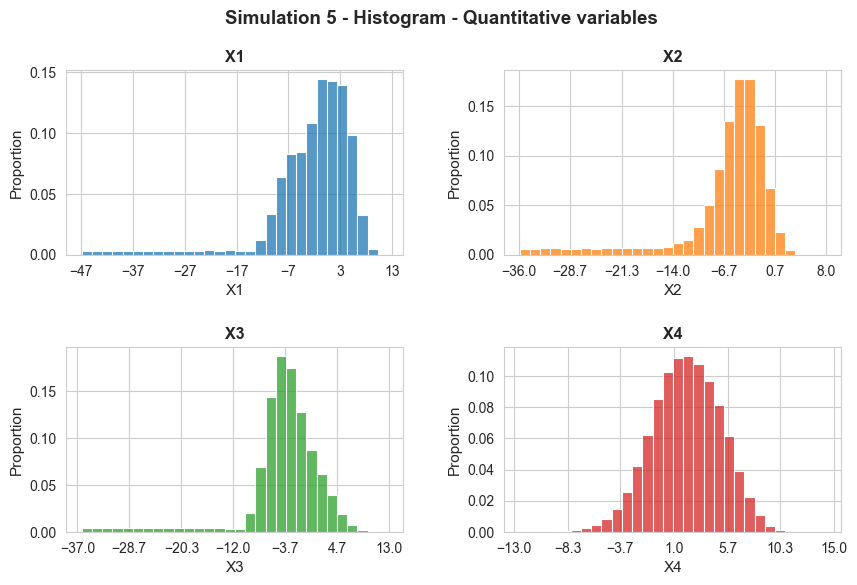

In [9]:
# Histogram
histogram_matrix(df=X_pl, bins=30, n_cols=2, 
                 title=f'{formatted_data_name} - Histogram - Quantitative variables', 
                 figsize=(10,6), quant_col_names=quant_predictors, 
                 n_xticks=7, title_fontsize=13.5, 
                 subtitles_fontsize=11.5, save=False, file_name='', x_rotation=0, title_height=0.98,
                 style='whitegrid', hspace=0.5, wspace=0.3, n_round_xticks=1)

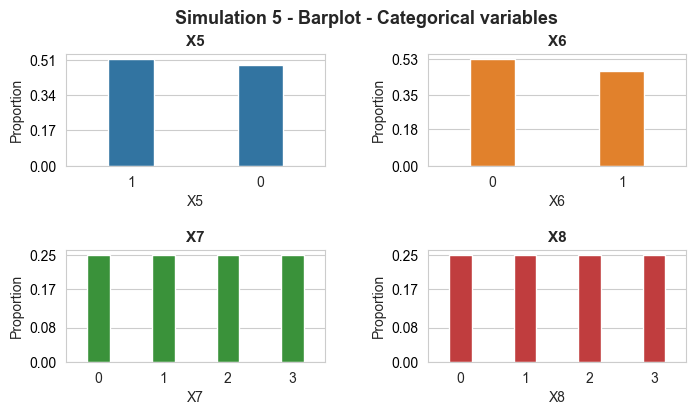

In [10]:
# Barplot
barplot_matrix(df=X_pl, n_cols=2, 
               title=f'{formatted_data_name} - Barplot - Categorical variables', 
                 figsize=(8,4), cat_col_names=cat_predictors,
                 title_fontsize=13, subtitles_fontsize=11, 
                 save=False, file_name='', x_rotation=0, title_height=0.99,
                 style='whitegrid', hspace=0.75, wspace=0.4, title_weight='bold', bar_width=0.35,
                 ylabel_size=10, xlabel_size=10, xticks_size=10)

In [11]:
# Correlation Matrix
X[quant_predictors].corr()

,X1,X2,X3,X4
X1,1.000000,0.586454,0.446956,0.053636
X2,0.586454,1.000000,0.531305,0.125195
X3,0.446956,0.531305,1.000000,-0.051555
X4,0.053636,0.125195,-0.051555,1.000000


In [12]:
# Correlation Analysis
corr_matrix = X[quant_predictors].corr().to_numpy()
n_corr = len(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
n_corr_below_30 = np.sum(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) < 0.30)
n_corr_above_60 = np.sum(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) > 0.60)
n_corr_between = np.sum((np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) >= 0.30) & (np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) <= 0.60))
                        
print('Proportion of pair-wise correlation > 0.60 (in abs. value): ', np.round(n_corr_above_60 / n_corr, 2))
print('Proportion of pair-wise correlations in [0.30, 0.60]: ', np.round(n_corr_between / n_corr, 2))
print('Proportion of pair-wise correlation < 0.30 (in abs. value): ', np.round(n_corr_below_30 / n_corr, 2))

Proportion of pair-wise correlation > 0.60 (in abs. value):  0.0
Proportion of pair-wise correlations in [0.30, 0.60]:  0.5
Proportion of pair-wise correlation < 0.30 (in abs. value):  0.5


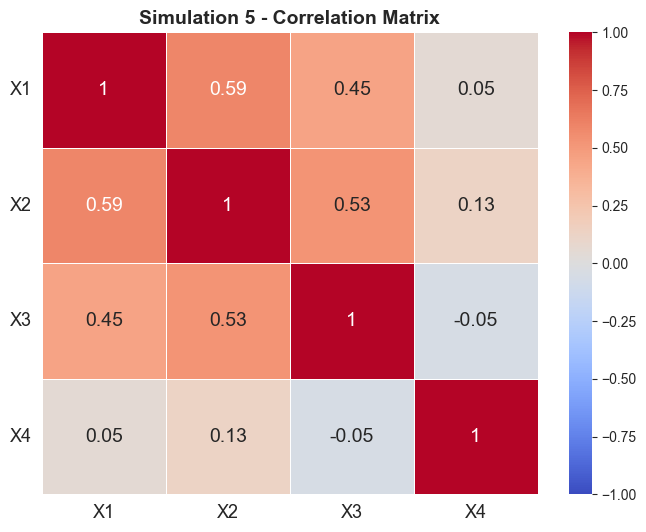

In [13]:
# Matriz de correlaciones
corr = X[quant_predictors].corr().round(2)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr, 
    annot=True,                 # Muestra los valores dentro de las celdas
    cmap="coolwarm",            # Paleta de colores
    vmin=-1, vmax=1,             # Escala del colorbar
    linewidths=0.5,             # Líneas entre celdas
    annot_kws={"size": 14}      # Tamaño del texto dentro de las celdas
)

# Personalizar etiquetas
plt.xticks(fontsize=13)         # Tamaño etiquetas eje X
plt.yticks(fontsize=13, rotation=0)  # Tamaño etiquetas eje Y (sin rotación)
plt.title(f"{formatted_data_name} - Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()
